In [3]:
import pandas as pd
import json
from tqdm import tqdm
from json import JSONDecodeError
import pickle

tqdm.pandas()
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 200 # DPI 고화질로 향상
plt.rcParams['font.family'] = 'NanumGothic'
import seaborn as sns

from mpire import WorkerPool
import multiprocessing
n_cpu = multiprocessing.cpu_count()
from itertools import chain
import glob
from natsort import natsorted
from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal

from kiwipiepy import Kiwi
kiwi = Kiwi(model_type='sbg')

In [2]:
df = pd.read_csv('./reply_df_kome_merge_token_ada.csv')
df

,idx,reply_user_id,Condemning,Praising,Suffering,Self-Conscious,user_type,title_p/n,e_policy_p/n,tokens_len,ttr
0,0,NXIM,0.997376,0.006453,0.004827,0.036101,normal,Neutral,Negative,42,0.857143
1,0,2Mh8r,0.998107,0.004667,0.007348,0.129774,normal,Neutral,Negative,59,0.847458
2,0,81WDL,0.993367,0.008692,0.004229,0.011016,normal,Neutral,Negative,17,1.000000
3,0,vHmK,0.621771,0.031186,0.391626,0.315763,normal,Neutral,Negative,15,1.000000
4,219,vHmK,0.995902,0.005379,0.004839,0.027142,normal,Negative,Negative,27,0.777778
...,...,...,...,...,...,...,...,...,...,...,...
50981,505,6iEMH,0.995683,0.003802,0.010997,0.040116,normal,Negative,Negative,12,1.000000
50982,505,1Wxev,0.994993,0.006516,0.004977,0.019645,normal,Negative,Negative,21,0.857143
50983,505,1HfFX,0.328715,0.450303,0.026757,0.033227,heavy,Negative,Negative,16,0.937500
50984,505,2vgvO,0.994564,0.016749,0.027052,0.155871,heavy,Negative,Negative,13,1.000000


/home/bjkim/miniconda3/envs/python311/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/bjkim/miniconda3/envs/python311/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/bjkim/miniconda3/envs/python311/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/bjkim/miniconda3/envs/python311/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be remov

[Text(0, 0, 'Condemning'),
 Text(1, 0, 'Praising'),
 Text(2, 0, 'Suffering'),
 Text(3, 0, 'Self-Conscious')]

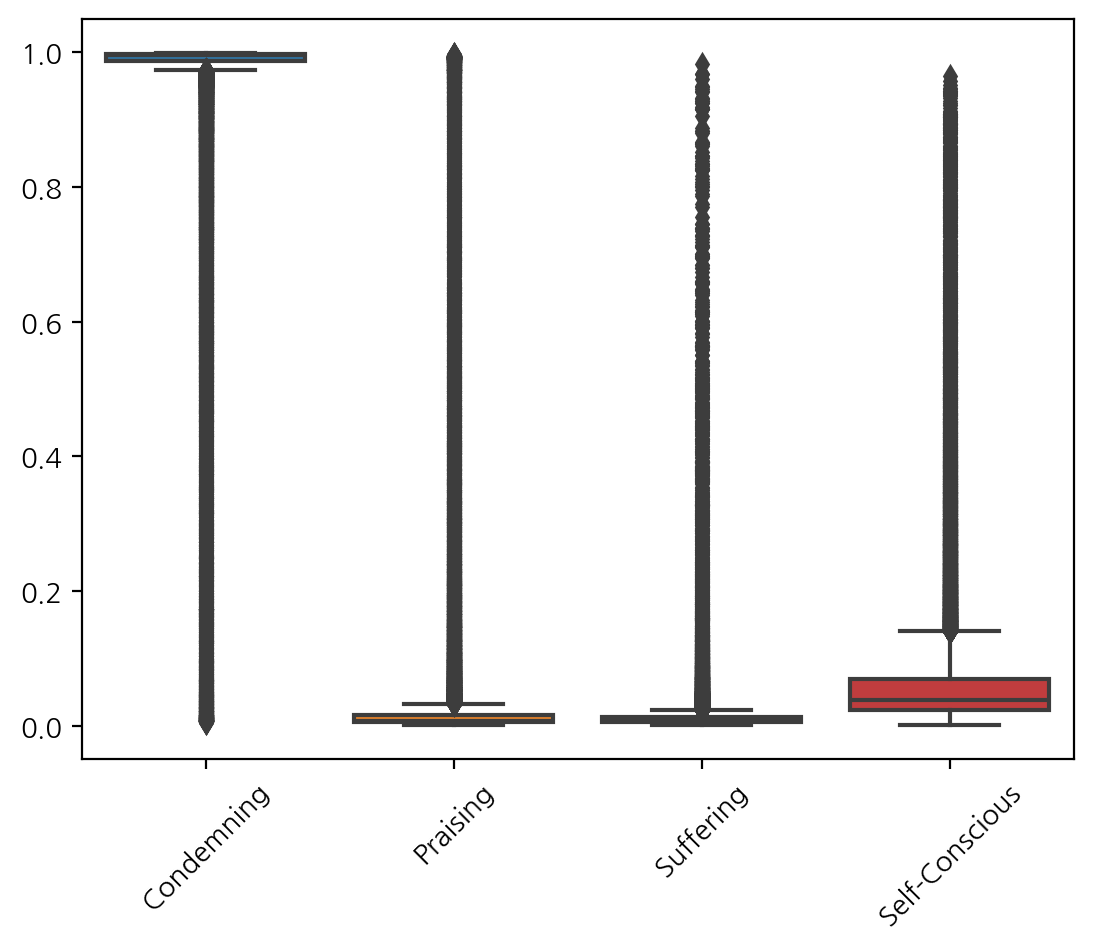

In [6]:
g = sns.boxplot(data = df[['Condemning', 'Praising', 'Suffering','Self-Conscious']])
g.set_xticklabels(g.get_xticklabels(), rotation=45)

In [4]:
# Define a function to perform the Kruskal-Wallis H test for the dependent variable based on the specified group column
def perform_kruskal_test_single(df, group_column, dependent_var):
    groups = [df[dependent_var][df[group_column] == group].values for group in df[group_column].unique() if group == group]  # Exclude NaN groups
    h_stat, p_val = kruskal(*groups)
    return h_stat, p_val

# Perform the Kruskal-Wallis H test based on 'user_type', 'title_p/n', and 'e_policy_p/n' for 'Condemning' and store the results
kruskal_results_single = {
    'user_type': perform_kruskal_test_single(df, 'user_type', 'Condemning'),
    'title_p/n': perform_kruskal_test_single(df, 'title_p/n', 'Condemning'),
    'e_policy_p/n': perform_kruskal_test_single(df, 'e_policy_p/n', 'Condemning')
}

kruskal_results_single

{'user_type': (1.0369445727936584, 0.30853314967972884),
 'title_p/n': (104.15528033767248, 2.415284220980935e-23),
 'e_policy_p/n': (1.7281880675245762, 0.42143318396478857)}

In [7]:
df.groupby('title_p/n')['Condemning'].describe()

,count,mean,std,min,25%,50%,75%,max
title_p/n,,,,,,,,
Negative,34255.0,0.944062,0.170728,0.004469,0.988974,0.995871,0.997191,0.999108
Neutral,12502.0,0.935205,0.183066,0.004847,0.985887,0.995772,0.997217,0.999018
Positive,4229.0,0.910104,0.227859,0.004860,0.977628,0.995182,0.997013,0.998919
